In [1]:
import pandas as pd

# =========
# データ読み込み
# =========
path = r"C:\Users\spax2\OneDrive\ドキュメント\PythonWork\ExcelDATA\データ表1.xlsx"
df = pd.read_excel(path, sheet_name="Sheet4")

# 列名の前後空白対策
df.columns = df.columns.map(lambda x: str(x).strip())

# 日付を datetime に
df["日付"] = pd.to_datetime(df["日付"])

# 数値列を数値化
cols_numeric = [
    "血糖値",
    "血圧収縮期",
    "中程度運動量（分）",
    "運動消費カロリー",
    "歩数",
]

for c in cols_numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")

 # ★ ここだけ追加（翌朝用）
df["血糖値_翌朝"] = df["血糖値"].shift(-1)
df["血圧収縮期_翌朝"] = df["血圧収縮期"].shift(-1)

df_lag = df.dropna(subset=["血糖値_翌朝", "血圧収縮期_翌朝"]).copy() 

# =========
# 年間平均値
# =========
targets = ["中程度運動量（分）", "運動消費カロリー", "歩数"]
annual_means = df[targets].mean()

annual_means


中程度運動量（分）     204.257143
運動消費カロリー      375.469914
歩数           7173.359195
dtype: float64

In [2]:
def analyze_tertiles_by_mean_nextday(df, activity_col):
    """
    activity_col の年間平均を基準に
    低(<=1/3), 中(>1/3 & <2/3), 高(>=2/3)
    で翌朝の血糖値・血圧収縮期を比較する
    """
    m = df[activity_col].mean()
    t1 = m / 3
    t2 = m * 2 / 3

    # 区分（低・中・高）
    def _bucket(x):
        if pd.isna(x):
            return None
        if x <= t1:
            return "低(<=1/3平均)"
        elif x < t2:
            return "中(1/3超-2/3未満)"
        else:
            return "高(>=2/3平均)"

    tmp = df[[activity_col, "血糖値_翌朝", "血圧収縮期_翌朝"]].copy()
    tmp["区分"] = tmp[activity_col].map(_bucket)
    tmp = tmp.dropna(subset=["区分"])

    # 区分ごとの平均・件数
    agg = (
        tmp.groupby("区分")
           .agg(
               日数=(activity_col, "size"),
               血糖値_翌朝平均=("血糖値_翌朝", "mean"),
               血圧収縮期_翌朝平均=("血圧収縮期_翌朝", "mean"),
           )
           .reindex(["低(<=1/3平均)", "中(1/3超-2/3未満)", "高(>=2/3平均)"])
    )

    # 低・高の差（高−低）
    diff_g = agg.loc["高(>=2/3平均)", "血糖値_翌朝平均"] - agg.loc["低(<=1/3平均)", "血糖値_翌朝平均"]
    diff_bp = agg.loc["高(>=2/3平均)", "血圧収縮期_翌朝平均"] - agg.loc["低(<=1/3平均)", "血圧収縮期_翌朝平均"]

    summary = {
        "項目": activity_col,
        "年間平均": m,
        "閾値_1/3": t1,
        "閾値_2/3": t2,
        "血糖値_翌朝_高-低": diff_g,
        "血圧収縮期_翌朝_高-低": diff_bp,
        "低_日数": agg.loc["低(<=1/3平均)", "日数"],
        "中_日数": agg.loc["中(1/3超-2/3未満)", "日数"],
        "高_日数": agg.loc["高(>=2/3平均)", "日数"],
    }

    return pd.DataFrame([summary]), agg.reset_index().rename(columns={"区分": "区分"})



In [3]:
targets = ["中程度運動量（分）", "運動消費カロリー", "歩数"]

summaries = []
details = {}

for col in targets:
    summary_df, agg_df = analyze_tertiles_by_mean_nextday(df_lag, col)
    summaries.append(summary_df)
    details[col] = agg_df

result_summary = pd.concat(summaries, ignore_index=True).round(2)
result_summary


,項目,年間平均,閾値_1/3,閾値_2/3,血糖値_翌朝_高-低,血圧収縮期_翌朝_高-低,低_日数,中_日数,高_日数
0,中程度運動量（分）,206.33,68.78,137.56,-4.51,-4.92,73,57,205
1,運動消費カロリー,377.80,125.93,251.87,-2.77,-4.86,58,75,201
2,歩数,7142.75,2380.92,4761.83,-3.21,-5.18,14,93,226


In [4]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "IPAexGothic"
matplotlib.rcParams["axes.unicode_minus"] = False  # マイナス記号対策


In [5]:
# matplotlibで日本語を使う。font.familyを変更する
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = 'HGMinchoB'

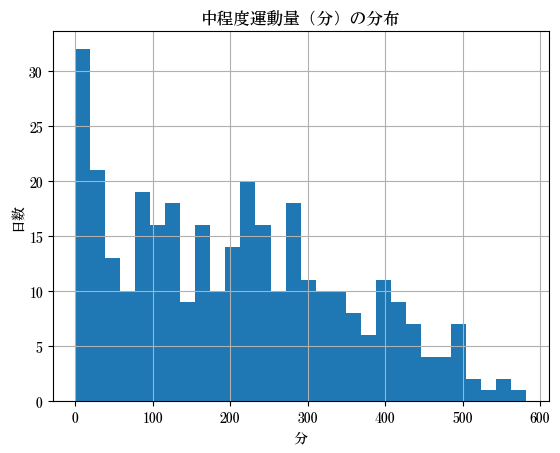

In [6]:
import matplotlib.pyplot as plt

plt.figure()
df_lag["中程度運動量（分）"].hist(bins=30)
plt.title("中程度運動量（分）の分布")
plt.xlabel("分")
plt.ylabel("日数")
plt.show()


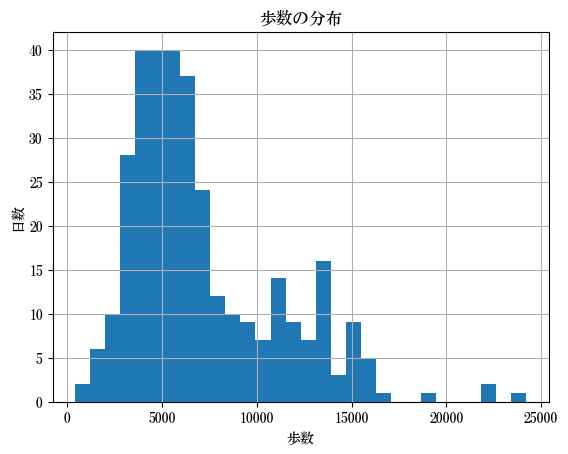

In [7]:
plt.figure()
df_lag["歩数"].hist(bins=30)
plt.title("歩数の分布")
plt.xlabel("歩数")
plt.ylabel("日数")
plt.show()


In [8]:
def season_quarter(month):
    if month <= 3:
        return "1-3月"
    elif month <= 6:
        return "4-6月"
    elif month <= 9:
        return "7-9月"
    else:
        return "10-12月"

df_lag["季節"] = df_lag["日付"].dt.month.map(season_quarter)


In [9]:
season_summary = (
    df_lag
    .groupby("季節")
    .agg(
        日数=("日付", "count"),
        血糖値_翌朝平均=("血糖値_翌朝", "mean"),
        血圧収縮期_翌朝平均=("血圧収縮期_翌朝", "mean"),
    )
    .reindex(["1-3月", "4-6月", "7-9月", "10-12月"])
)

season_summary = season_summary.round(2)
season_summary


,日数,血糖値_翌朝平均,血圧収縮期_翌朝平均
季節,,,
1-3月,85,124.56,124.86
4-6月,88,122.28,118.06
7-9月,88,117.08,118.15
10-12月,77,123.35,127.75


In [10]:
def season_quarter(m):
    if m <= 3:
        return "1-3月"
    elif m <= 6:
        return "4-6月"
    elif m <= 9:
        return "7-9月"
    else:
        return "10-12月"

df_lag = df_lag.copy()
df_lag["季節"] = df_lag["日付"].dt.month.map(season_quarter)

season_order = ["1-3月", "4-6月", "7-9月", "10-12月"]


C:\Users\spax2\AppData\Local\Temp\ipykernel_58596\3327695100.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_g, labels=season_order, showmeans=True)


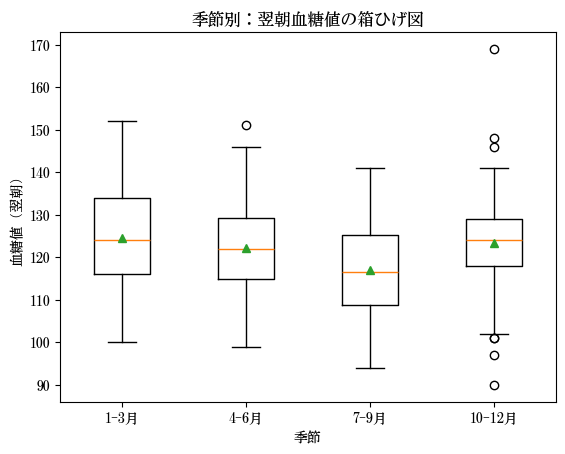

C:\Users\spax2\AppData\Local\Temp\ipykernel_58596\3327695100.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_bp, labels=season_order, showmeans=True)


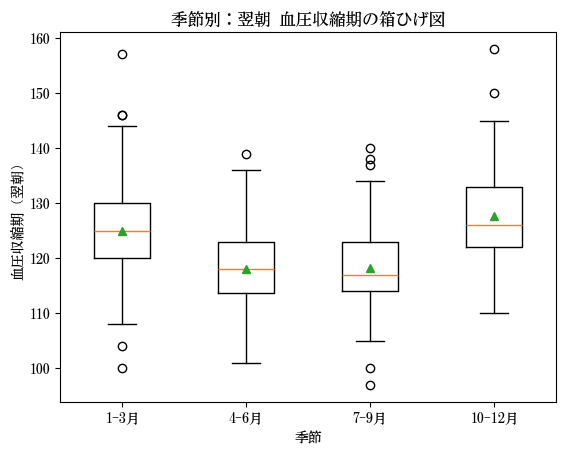

In [11]:
from matplotlib import pyplot as plt

# 文字化け/マイナス対策（念のため）
plt.rcParams["font.family"] = "HGMinchoB"
plt.rcParams["axes.unicode_minus"] = False

# --- 血糖値（翌朝） ---
plt.figure()
data_g = [df_lag.loc[df_lag["季節"] == s, "血糖値_翌朝"].dropna() for s in season_order]
plt.boxplot(data_g, labels=season_order, showmeans=True)
plt.title("季節別：翌朝血糖値の箱ひげ図")
plt.xlabel("季節")
plt.ylabel("血糖値（翌朝）")
plt.show()

# --- 血圧収縮期（翌朝） ---
plt.figure()
data_bp = [df_lag.loc[df_lag["季節"] == s, "血圧収縮期_翌朝"].dropna() for s in season_order]
plt.boxplot(data_bp, labels=season_order, showmeans=True)
plt.title("季節別：翌朝 血圧収縮期の箱ひげ図")
plt.xlabel("季節")
plt.ylabel("血圧収縮期（翌朝）")
plt.show()


In [ ]:
activity_col = "中程度運動量（分）"
m = df_lag[activity_col].mean()
t1 = m / 3
t2 = m * 2 / 3

def bucket_3(x):
    if pd.isna(x):
        return None
    if x <= t1:
        return "低(<=1/3平均)"
    elif x < t2:
        return "中(1/3超-2/3未満)"
    else:
        return "高(>=2/3平均)"

df_lag["運動区分"] = df_lag[activity_col].map(bucket_3)
bucket_order = ["低(<=1/3平均)", "中(1/3超-2/3未満)", "高(>=2/3平均)"]


In [ ]:
count_table = (
    df_lag.pivot_table(index="季節", columns="運動区分", values="日付", aggfunc="count")
    .reindex(index=season_order, columns=bucket_order)
    .fillna(0)
    .astype(int)
)
count_table


In [ ]:
mean_glucose = (
    df_lag.pivot_table(index="季節", columns="運動区分", values="血糖値_翌朝", aggfunc="mean")
    .reindex(index=season_order, columns=bucket_order)
)
mean_bp = (
    df_lag.pivot_table(index="季節", columns="運動区分", values="血圧収縮期_翌朝", aggfunc="mean")
    .reindex(index=season_order, columns=bucket_order)
)

mean_glucose.round(2), mean_bp.round(2)


In [ ]:
summary_long = (
    df_lag.groupby(["季節", "運動区分"])
    .agg(
        日数=("日付", "count"),
        血糖値_翌朝平均=("血糖値_翌朝", "mean"),
        血圧収縮期_翌朝平均=("血圧収縮期_翌朝", "mean"),
    )
    .reindex(pd.MultiIndex.from_product([season_order, bucket_order], names=["季節","運動区分"]))
    .reset_index()
)

summary_long = summary_long.round(2)
summary_long
